In [ ]:
from pathlib import Path
import datetime as dt
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import dates as md

In [ ]:
PROJPATH = Path().resolve().parent
breakupfpth = PROJPATH / "data/breakupdata/derived/breakupDate_cleaned_selected.csv"
brokenuppth = PROJPATH / "data/DDforecast_2025/broken_up_2025.csv"
combindedpth = PROJPATH / "data/weatherstations/ACIS_combined_DD"
locationprefix = "DD25_combined_"

In [ ]:
breakup = pd.read_csv(breakupfpth, skiprows=3, index_col=0)
breakup

,id,siteID,year,breakup,JulianDay
1909,209,Buckland River at Buckland,1983,1983-05-12,132
1908,210,Buckland River at Buckland,1984,1984-05-23,144
1757,1067,Buckland River at Buckland,1985,1985-05-26,146
1907,211,Buckland River at Buckland,1986,1986-05-30,150
1906,212,Buckland River at Buckland,1987,1987-05-22,142
...,...,...,...,...,...
197,7029,Yukon River nr Emmonak,2020,2020-05-14,135
157,7081,Yukon River nr Emmonak,2021,2021-05-13,133
113,7160,Yukon River nr Emmonak,2022,2022-05-15,135
52,7236,Yukon River nr Emmonak,2023,2023-05-27,147


In [ ]:
siteIDs = breakup.siteID.unique()
testsite = 'Kuskokwim River at Nikolai'
testdd = pd.read_csv(combindedpth / f"{locationprefix}{testsite.replace(' ', '_')}.csv", skiprows=3)
testdd_melted = testdd.melt(id_vars=['julian_day'], value_vars=testdd.columns[1:], var_name='year', value_name='dd25')
testdd_melted.set_index(['julian_day', 'year'], inplace=True)
testdd_melted

,,dd25
julian_day,year,
60,1980,NaN
61,1980,0.00
62,1980,0.00
63,1980,0.00
64,1980,0.00
...,...,...
178,1993,2207.41
179,1993,2241.91
180,1993,2280.41


In [ ]:
broken_up = pd.read_csv(brokenuppth, index_col=0)
broken_up

,breakup
location,
Yukon River at Dawson,2025-04-30
Yukon River at Eagle,2025-05-01
Yukon River at Circle,2025-05-05
Yukon River at Fort Yukon,2025-05-06
Kuskokwim River at Nikolai,2025-04-22
Kuskokwim River at McGrath,2025-05-03
Yukon River at Galena,2025-05-08
Kuskokwim River at Crooked Creek,2025-04-28
Kuskokwim River at Sleetmute,2025-04-27


In [ ]:
actualbreakup = broken_up.loc[testsite].item()

In [ ]:
breakupdd25 = []
for _, year, JulianDay in  breakup[breakup.siteID==testsite][['year', 'JulianDay']].itertuples():
    breakupdd25.append([year, JulianDay, testdd_melted.loc[(JulianDay, str(year)), 'dd25']])
breakupdd25DF = pd.DataFrame(breakupdd25)
breakupdd25DF.columns = ['year', 'JulianDay', 'DD25']
breakupdd25DF['thedate'] = pd.to_datetime(breakupdd25DF.JulianDay-1, unit='D',
               origin=pd.Timestamp('2025-01-01'))
breakupdd25DF


,year,JulianDay,DD25,thedate
0,1984,124,329.00,2025-05-04
1,1985,129,253.00,2025-05-09
2,1986,125,212.84,2025-05-05
3,1988,117,329.50,2025-04-27
4,1990,102,151.50,2025-04-12
5,1991,114,191.00,2025-04-24
6,1992,115,188.50,2025-04-25
7,1993,103,179.50,2025-04-13
8,1994,112,245.25,2025-04-22
9,1995,107,208.75,2025-04-17


In [ ]:
meandd25, stddd25 = breakupdd25DF.DD25.mean(), breakupdd25DF.DD25.std()

In [ ]:
testdd['thedate'] = pd.to_datetime(testdd.julian_day-1, unit='D',
               origin=pd.Timestamp('2025-01-01'))
testdd.set_index('thedate', inplace=True)
testdd['2025-04-01':'2025-05-02']

,julian_day,1980,1981,1982,1983,1984,1985,1986,1987,1988,...,2020,2021,2022,2023,2024,2025,1990,1991,1992,1993
thedate,,,,,,,,,,,,,,,,,,,,,
2025-04-01,91,81.25,150.25,48.50,0.00,94.00,30.00,1.25,89.00,75.75,...,44.33,7.67,25.83,16.25,96.67,35.83,56.5,18.5,52.0,46.0
2025-04-02,92,99.50,155.25,48.50,0.00,104.00,30.00,1.25,90.25,75.75,...,44.67,7.67,25.83,16.25,100.83,44.67,60.5,18.5,52.0,56.5
2025-04-03,93,117.25,157.75,48.50,1.25,109.00,30.00,1.25,92.00,75.75,...,47.67,7.67,25.83,16.25,100.83,56.50,65.5,18.5,52.0,66.5
2025-04-04,94,130.50,158.25,48.50,11.00,118.00,30.00,1.25,92.00,75.75,...,53.17,8.33,25.83,21.00,100.83,70.50,81.5,20.0,52.0,72.5
2025-04-05,95,144.50,158.25,53.50,20.75,128.50,30.00,1.25,94.25,75.75,...,58.00,8.33,25.83,21.00,105.33,87.17,89.0,20.0,52.0,78.0
2025-04-06,96,151.25,158.25,66.00,26.75,137.00,30.00,1.25,95.75,75.75,...,61.83,8.33,28.67,21.00,111.83,94.17,94.0,20.0,52.0,87.0
2025-04-07,97,156.25,158.25,75.25,30.00,140.75,30.00,1.25,97.75,75.75,...,61.83,8.33,32.50,21.00,117.17,94.17,105.0,20.0,57.5,96.0
2025-04-08,98,164.50,158.25,77.00,31.75,142.00,30.00,1.25,102.00,75.75,...,61.83,8.33,32.50,21.00,122.83,94.17,119.5,23.0,57.5,108.0
2025-04-09,99,176.50,158.25,82.00,32.75,144.25,30.00,1.25,108.75,75.75,...,61.83,8.33,32.50,21.00,126.83,95.83,129.0,24.5,57.5,117.5


In [ ]:
sns.set_style('ticks')

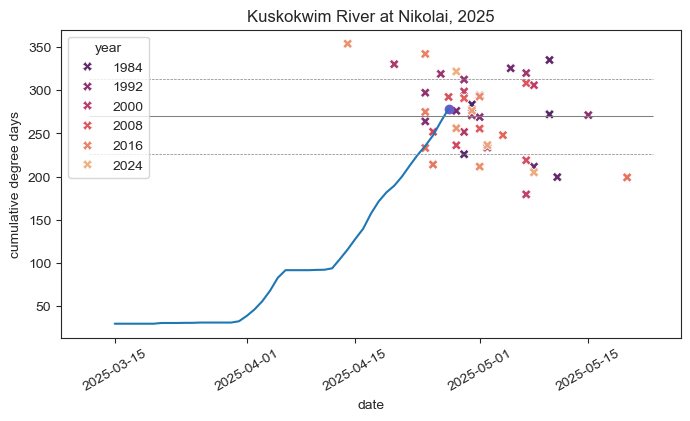

In [ ]:
fig = plt.subplots(figsize=(8, 4))
f = sns.lineplot(data=testdd['2025-03-15':actualbreakup], x='thedate', y='2025', )
g = sns.scatterplot(data=breakupdd25DF, x='thedate', y='DD25', hue='year', palette='flare_r', s=50, marker="X", ax=f)
plt.scatter(dt.datetime.strptime(actualbreakup, '%Y-%m-%d'), testdd.loc[actualbreakup]['2025'], color='slateblue')
xmin, _  = f.get_xlim()
_, xmax = g.get_xlim()
plt.hlines(y=meandd25, color='grey', xmin=xmin, xmax=xmax, lw=0.75,)
plt.hlines(y=[meandd25-stddd25, meandd25+stddd25], color='grey', linestyles='--', lw=0.5, xmin=xmin, xmax=xmax)
plt.xticks(rotation=30)
plt.xlabel('date')
plt.ylabel('cumulative degree days')
plt.title(f"{testsite}, 2025")
sns.move_legend(f, "upper left")
fn = f'final_cumul_{testsite.replace(' ', '_')}.png'
plt.savefig(fn, bbox_inches='tight')

### Loop through locations in broken_up file

Yukon River at Dawson broke up on 2025-04-30
Yukon River at Eagle broke up on 2025-05-01
Yukon River at Circle broke up on 2025-05-05
Yukon River at Fort Yukon broke up on 2025-05-06
Kuskokwim River at Nikolai broke up on 2025-04-22
Kuskokwim River at McGrath broke up on 2025-05-03
Yukon River at Galena broke up on 2025-05-08
Kuskokwim River at Crooked Creek broke up on 2025-04-28
Kuskokwim River at Sleetmute broke up on 2025-04-27
Kuskokwim River at Stony River broke up on 2025-04-27
Kuskokwim River at Red Devil broke up on 2025-04-28
Kuskokwim River at Akiak broke up on 2025-05-07
Kuskokwim River at Aniak broke up on 2025-05-01
Kuskokwim River at Kalskag broke up on 2025-05-05
Kuskokwim River at Tuluksak broke up on 2025-05-02
Kuskokwim River at Bethel broke up on 2025-05-06
Tanana River at Nenana broke up on 2025-04-27


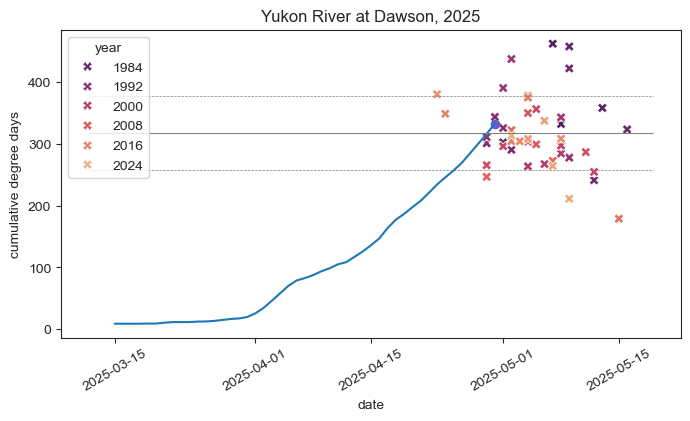

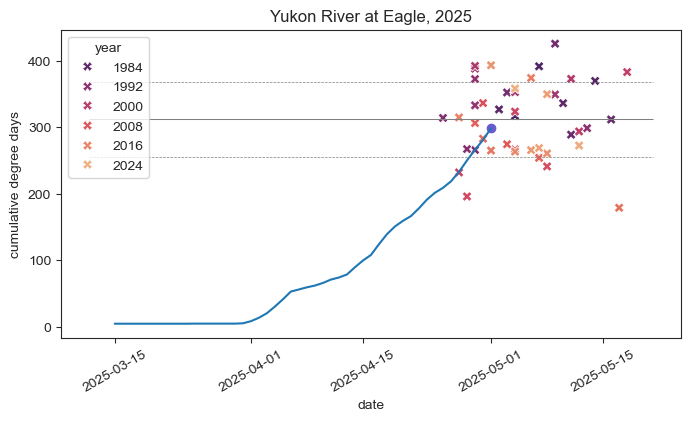

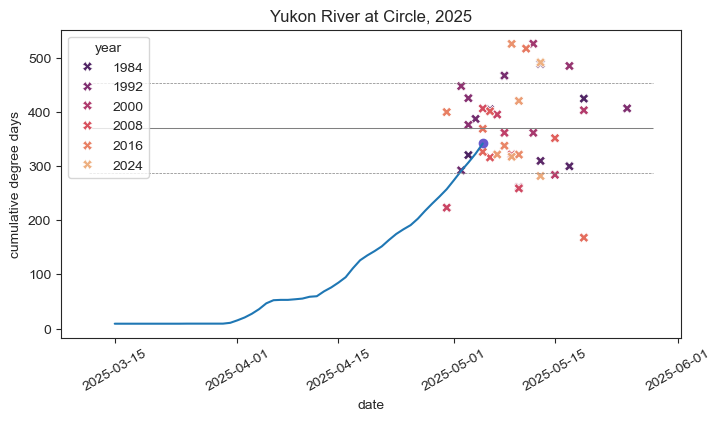

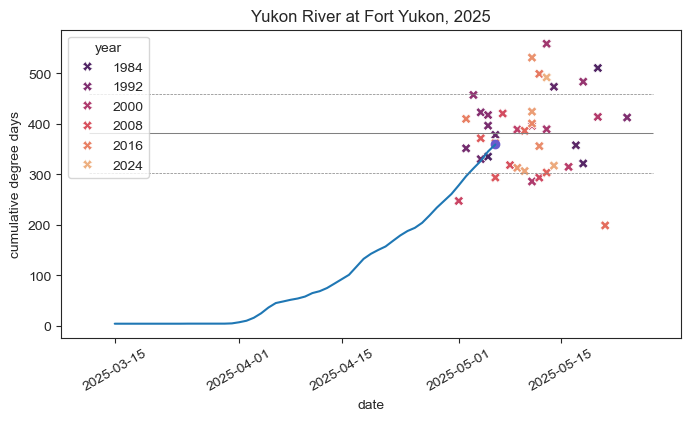

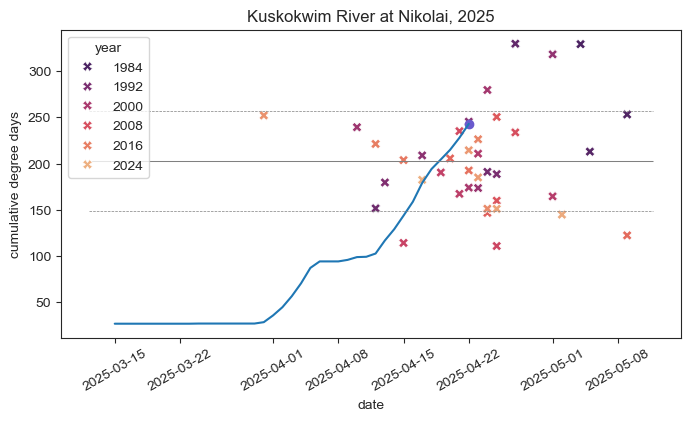

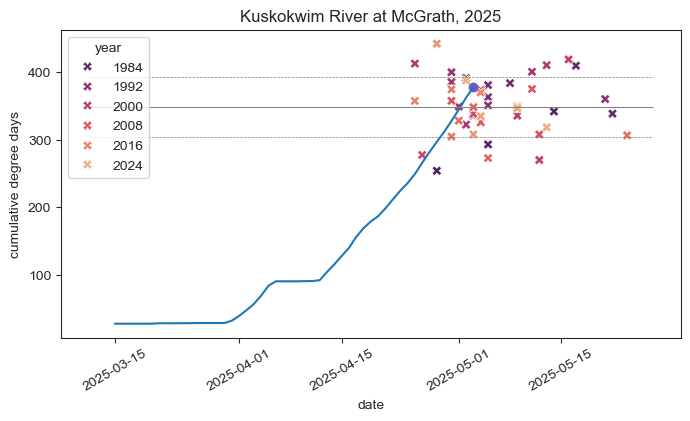

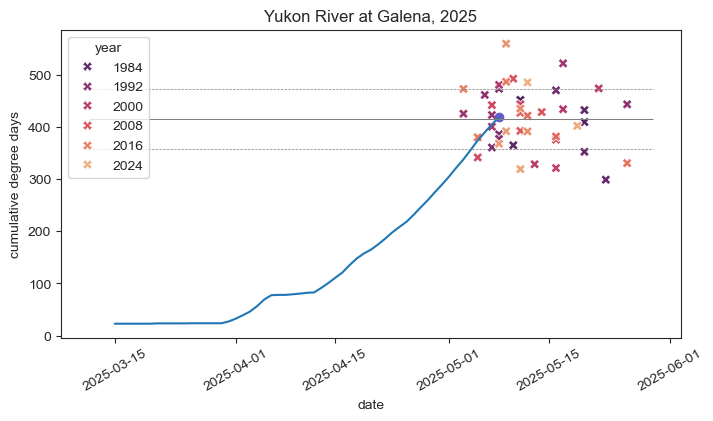

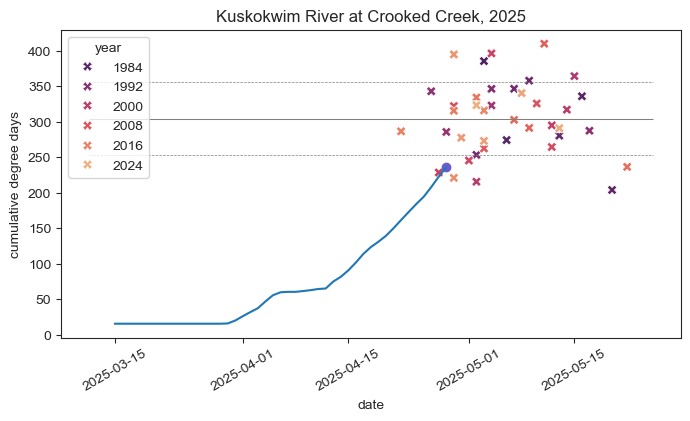

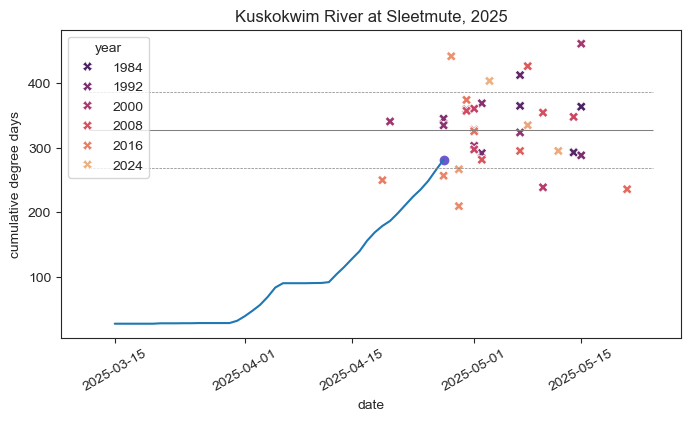

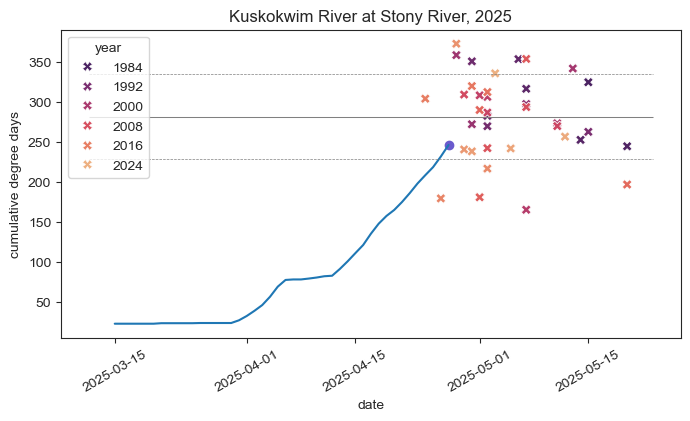

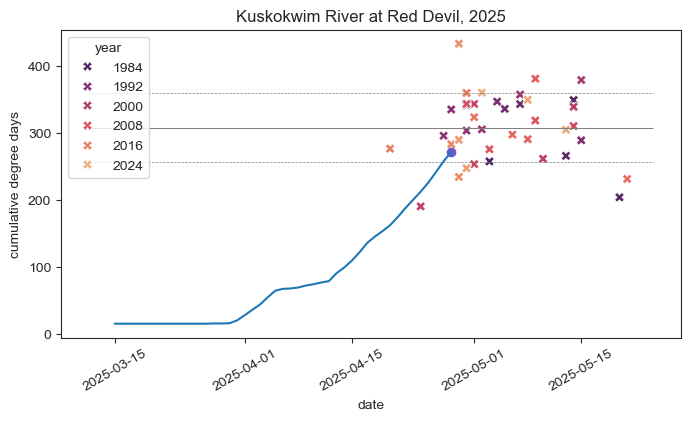

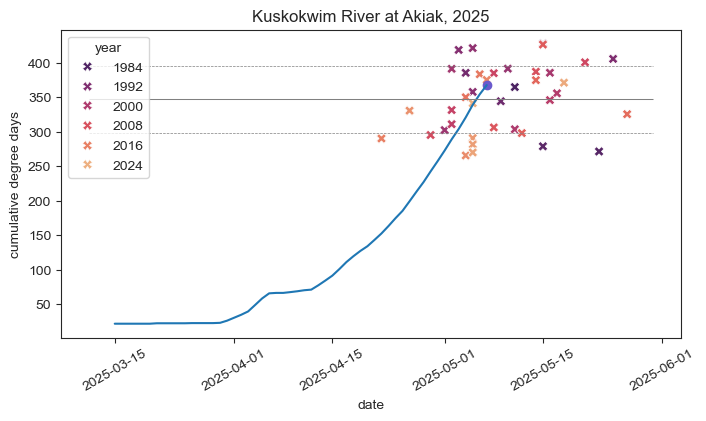

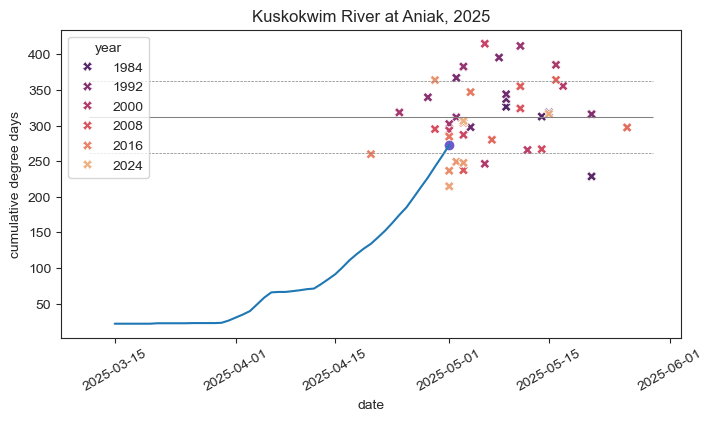

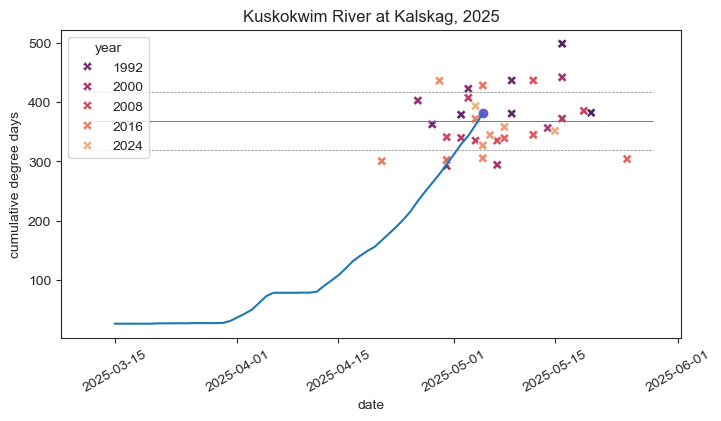

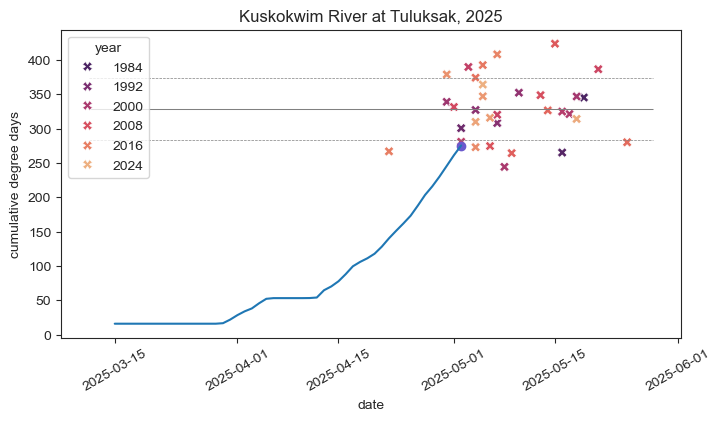

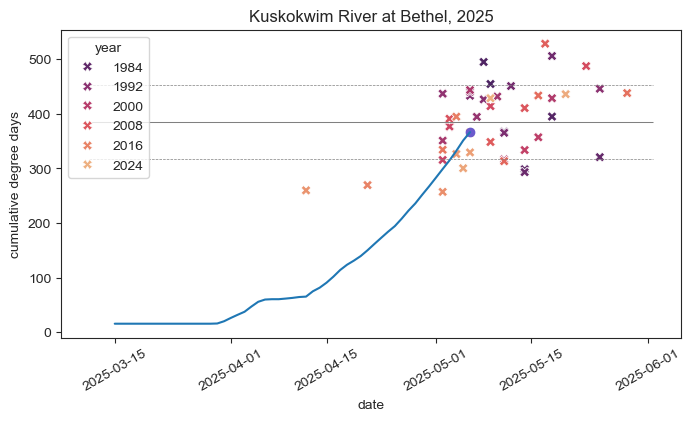

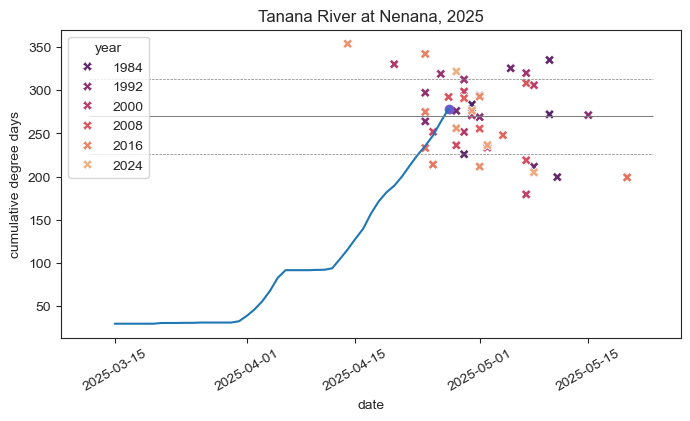

In [ ]:
for location, actualbreakup in broken_up.itertuples():
    print(location, "broke up on", actualbreakup)
    # load the combined DD25 averages for location
    testdd = pd.read_csv(combindedpth / f"{locationprefix}{location.replace(' ', '_')}.csv", skiprows=3)
    testdd_melted = testdd.melt(id_vars=['julian_day'], value_vars=testdd.columns[1:], var_name='year', value_name='dd25')
    testdd_melted.set_index(['julian_day', 'year'], inplace=True)
    # load historical breakupdate / DD25 values
    breakupdd25 = []
    for _, year, JulianDay in  breakup[breakup.siteID==location][['year', 'JulianDay']].itertuples():
        breakupdd25.append([year, JulianDay, testdd_melted.loc[(JulianDay, str(year)), 'dd25']])
    breakupdd25DF = pd.DataFrame(breakupdd25)
    breakupdd25DF.columns = ['year', 'JulianDay', 'DD25']
    breakupdd25DF['thedate'] = pd.to_datetime(breakupdd25DF.JulianDay-1, unit='D',
                origin=pd.Timestamp('2025-01-01'))
    # get mean and standard deviation of historical data
    meandd25, stddd25 = breakupdd25DF.DD25.mean(), breakupdd25DF.DD25.std()
    # make a datetime index for plotting of time series
    testdd['thedate'] = pd.to_datetime(testdd.julian_day-1, unit='D',
               origin=pd.Timestamp('2025-01-01'))
    testdd.set_index('thedate', inplace=True)
    # plot and save figure 
    fig = plt.subplots(figsize=(8, 4))
    f = sns.lineplot(data=testdd['2025-03-15':actualbreakup], x='thedate', y='2025', )
    g = sns.scatterplot(data=breakupdd25DF, x='thedate', y='DD25', hue='year', palette='flare_r', s=50, marker="X", ax=f)
    sns.move_legend(f, "upper left")
    plt.scatter(dt.datetime.strptime(actualbreakup, '%Y-%m-%d'), testdd.loc[actualbreakup]['2025'], color='slateblue')
    xmin, _  = f.get_xlim()
    _, xmax = g.get_xlim()
    plt.hlines(y=meandd25, color='grey', xmin=xmin, xmax=xmax, lw=0.75,)
    plt.hlines(y=[meandd25-stddd25, meandd25+stddd25], color='grey', linestyles='--', lw=0.5, xmin=xmin, xmax=xmax)
    plt.xticks(rotation=30)
    plt.xlabel('date')
    plt.ylabel('cumulative degree days')
    plt.title(f"{location}, 2025")

    fn = f'final_cumul_{location.replace(' ', '_')}.png'
    plt.savefig(fn, bbox_inches='tight')
    
